In [ ]:
import numpy as np                #number handling suite
import pandas as pd               #also handles numbers and is a pre-requisite for geopandas
import os                         #for commands around file management
import geopandas as gpd           #geospatial pandas suite
import shapely                    #shapefile manager
from shapely.geometry.polygon import Polygon

from osgeo import gdal            #a way to visualise and load .tiff files
import matplotlib.pyplot as plt   #main plotting module for python

!pip install cartopy              #Map tools module
import cartopy
import cartopy.crs as ccrs

from google.colab import files

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 107.8 MB/s eta 0:00:00


In [ ]:
os.getcwd() #so you know the current working directory

'/content'

## 3. Data visualisation

You now know how to load and manipulate data, now it would be nice to see it visualised!

### 3.1 Matplotlib

Much of the plotting you will do with python is in matplotlib. Matplot lib is a bit verbose but once you have it you can make highly customisable plots.

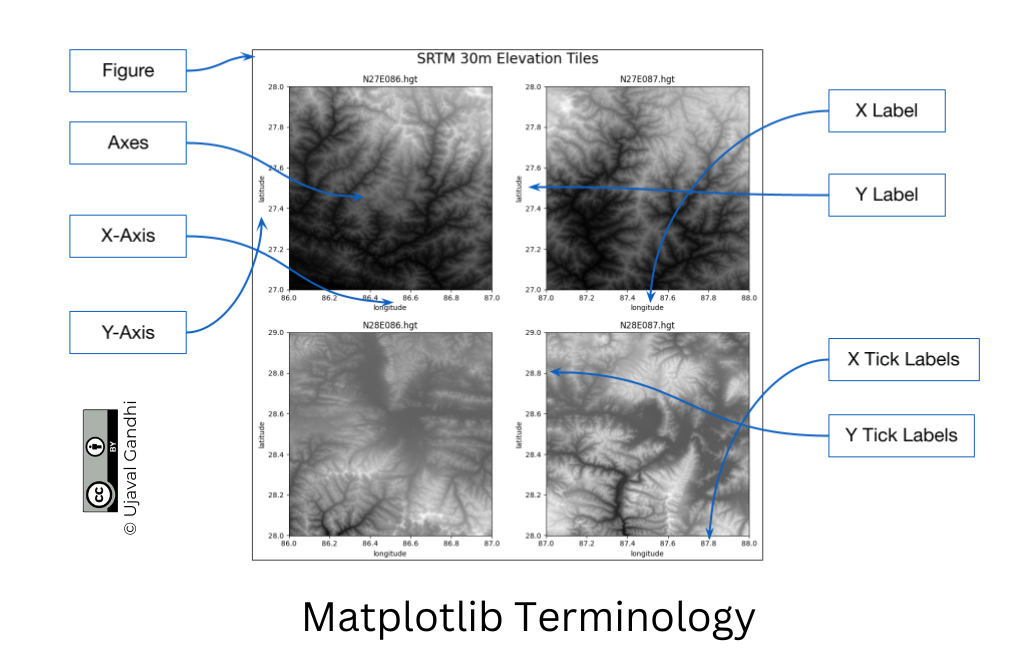

There are many different types of plots in matplotlib but the ones you will mostly use are ```plot```, ```scatterplot```, ```imshow```, and ```pcolormesh```, although you may also use ```bar``` but I won't show that one in the interest of time.

Here is the link to the matplotlib API for reference and extra reading:

(https://matplotlib.org/stable/api/matplotlib_configuration_api.html)

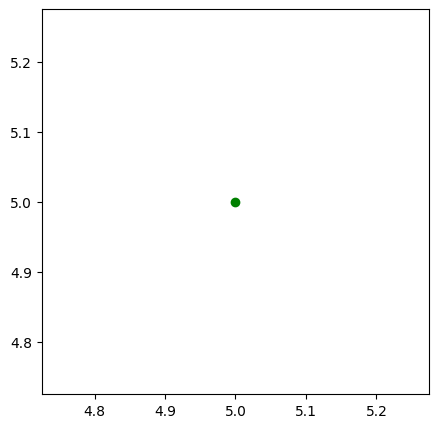

In [ ]:
sample_data_1 = (5,5) #make sample data
fig, ax = plt.subplots(figsize=(5, 5)) #Initialising the plot
ax.plot(sample_data_1[0], sample_data_1[1], color='green', marker='o')
plt.show()

Often data is represented as a tuple which will not plot as is.

In [ ]:
sample_data_2 = (52.3, -40.5), (55.6, -42), (60.2, -41.9)
type(sample_data_2)

tuple

using the ```zip``` funtion we can split the tuple data into two to make it easier to plot

In [ ]:
lat_points, lon_points = zip(*sample_data_2)
print(lat_points)
print(lon_points)

(52.3, 55.6, 60.2)
(-40.5, -42, -41.9)


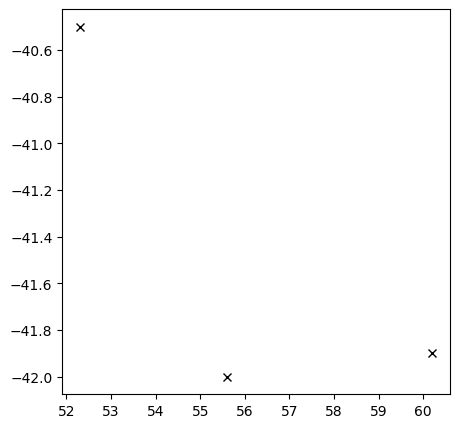

In [ ]:
sample_data_1 = (5,5)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(lat_points, lon_points, color='black', marker='x', linestyle="None")
plt.show()

You can also stack plots on the same axes to represent multiple datasets.

In [ ]:
rand_arr_1 = np.random.rand(10,2)
rand_arr_2 = np.random.rand(10,2)

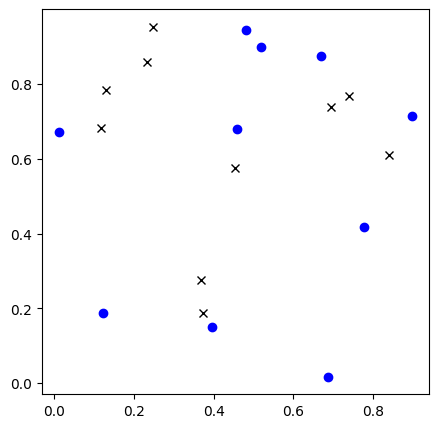

In [ ]:
sample_data_1 = (5,5)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(rand_arr_1[:,0], rand_arr_1[:,1], color='black', marker='x', linestyle="None")
ax.plot(rand_arr_2[:,0], rand_arr_2[:,1], color='blue', marker='o', linestyle="None")
plt.show()

#### 3.2.1 Subplots

Often you will want to put plots next to each other for ease of comparison

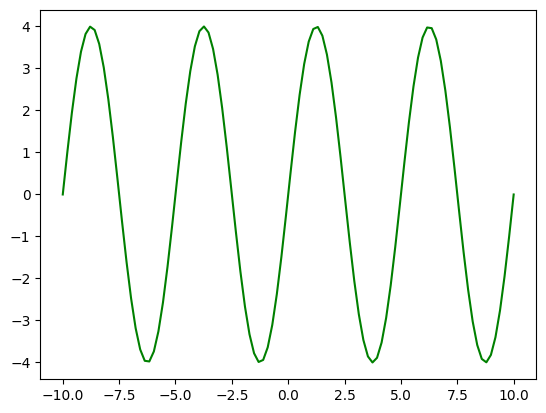

In [ ]:
#initialise some data
amplitude = 4, 2
wavelength = 5, 2
velocity = 2, 2
time = 0, 0

x_ = np.linspace(-10, 10, 100)

wave1 = amplitude[0] * np.sin((2*np.pi/wavelength[0]) * (x_ - velocity[0]*time[0]))

plt.plot(x_, wave1, color="green")
plt.show()


Now lets plot both waves together

Text(0.5, 0, 'Space')

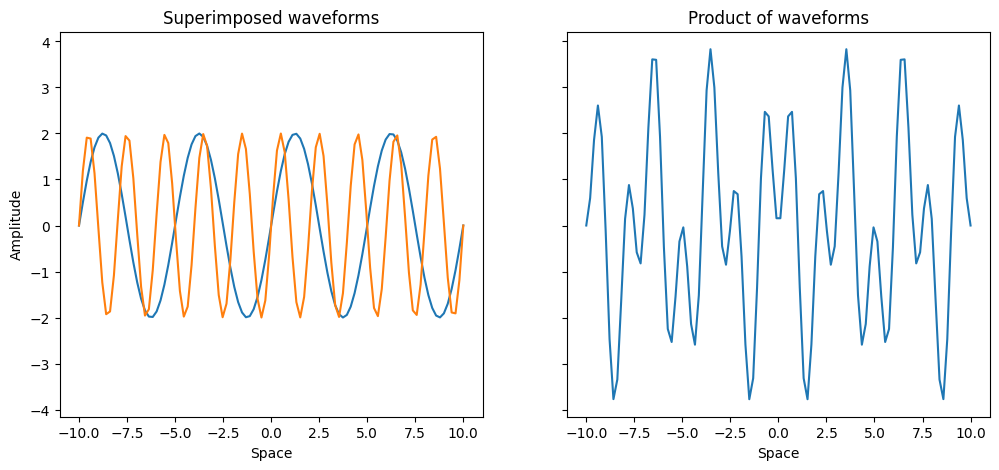

In [ ]:
wave2 = amplitude[1] * np.sin((2*np.pi/wavelength[1]) * (x_ - velocity[1]*time[1]))

fig, ax = plt.subplots(1,2, figsize=(12, 5), sharey=True, sharex=True)
ax[0].set_ylabel("Amplitude")
ax[0].set_title("Superimposed waveforms")
ax[0].plot(x_, wave1)
ax[0].plot(x_, wave2)
ax[0].set_xlabel("Space")
ax[1].set_title("Product of waveforms")
ax[1].plot(x_, wave1 * wave2)
ax[1].set_xlabel("Space")

### 3.2 ```linspace and arange```
Remember last class where we used the ```range``` command to make a range of elements? Here we can use similar commands to make an array of data.

Linspace and arange are ways to make a sequence of data that conforms to a pre-defined pattern, exactly like ```range```

The difference between the two is this:
- linspace returns evenly spaced numbers *over* a specified interval.
- arange returns evenly spaced values *within* a given interval.

If you are still confused or want more info then check out this page (https://realpython.com/np-linspace-numpy/)

We are also going to load some data from a GitHub repository I made

In [ ]:
!git clone "https://github.com/hannahsophiadavies/Geol_methods_GIS-datascience-python.git"

Cloning into 'Geol_methods_GIS-datascience-python'...
remote: Enumerating objects: 47, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 47 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (47/47), 12.30 MiB | 7.73 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [ ]:
np.arange(0,10,1) #go from 0 to 10 in steps of 1 (predefined steps)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
np.linspace(0,10,10) #go from 0 to 10 in 10 steps (predefined division of the sequence)

array([ 0.        ,  1.11111111,  2.22222222,  3.33333333,  4.44444444,
        5.55555556,  6.66666667,  7.77777778,  8.88888889, 10.        ])

Lets use an example to show how these functions can help with data plotting

In [ ]:
#Import DEM map
gdal.UseExceptions()
ds = gdal.Open("/content/Geol_methods_GIS-datascience-python/marseigthdeg-DEM.tif")

band = ds.GetRasterBand(1)
dem = band.ReadAsArray()
print(dem.shape)

(1440, 2880)


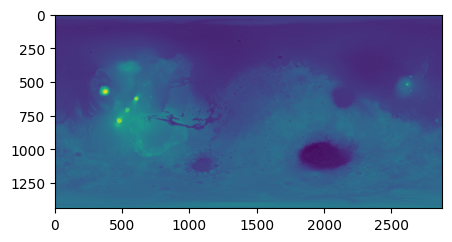

In [ ]:
fig, ax = plt.subplots(figsize=(5, 10)) #initialise a plot and set the size of it
plt.imshow(dem) #use "imshow" to plot the data

Lets go over some of the most common commands to use in matplotlib to edit the plot(s)

#### 3.2.1 Colormaps
Colormaps affect the color range you use to plot data. See a list of built in ones here

(https://matplotlib.org/stable/users/explain/colors/colormaps.html)

Consider the kind of data you are plotting and also try to use color-blind friendly color-schemes if you can help it.

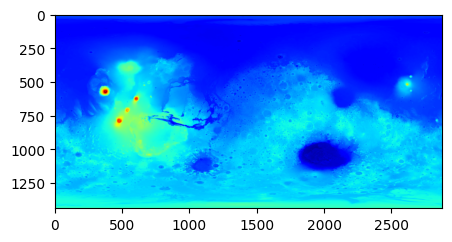

In [ ]:
fig, ax = plt.subplots(figsize=(5, 10))
plt.imshow(dem, cmap='jet') #change the colormap

Invert colormaps by adding ```_r``` to the end of the colormap name

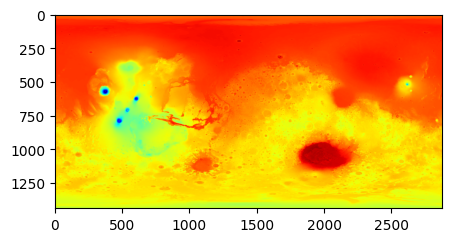

In [ ]:
fig, ax = plt.subplots(figsize=(5, 10))
plt.imshow(dem, cmap='jet_r') #Flip the colormap

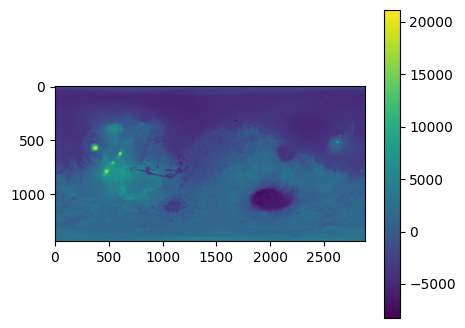

In [ ]:
fig, ax = plt.subplots(figsize=(5,10))
im = plt.imshow(dem)
plt.colorbar(shrink=0.4) #make a colorbar and shrink it to fit the size of the plot better

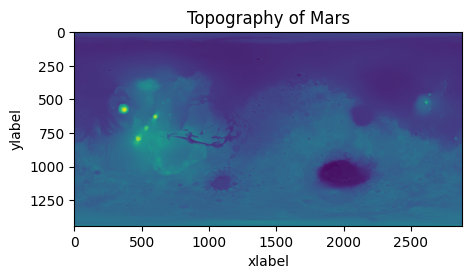

In [ ]:
fig, ax = plt.subplots(figsize=(5,10))
im = plt.imshow(dem)
plt.title("Topography of Mars") #add title and labels to the axes
plt.ylabel('ylabel')
plt.xlabel('xlabel');

Here we loaded in a DEM (Digital Elevation Model) of Mars but it is not georeferenced and when we plot it the axes are displayed as the length of the array (1440 x 2880). As we know the array size we can use linspace to make latitude and longitude axes.

In [ ]:
len(dem), len(dem[0]) #can also put dem.shape

(1440, 2880)

In [ ]:
lon=np.linspace(-180,180,(len(dem[0]))) #make an array of variables of length 2880 starting at -180 and ending at 180 to use as the x-axis or columns
print(lon.shape)

(2880,)


In [ ]:
lat=np.linspace(90,-90,len(dem)) #make an array of variables of length 1440 starting at 90 and ending at -90 to use as the y-axis or rows
print(lat.shape)

(1440,)


What I did here was make two linspaces ```lat``` and ```lon``` which iterate through latitude and longitude at the length of the ```dem``` array

Now we can use these linspaces when we plot ```dem``` to make the figure more accurate and easier to read

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

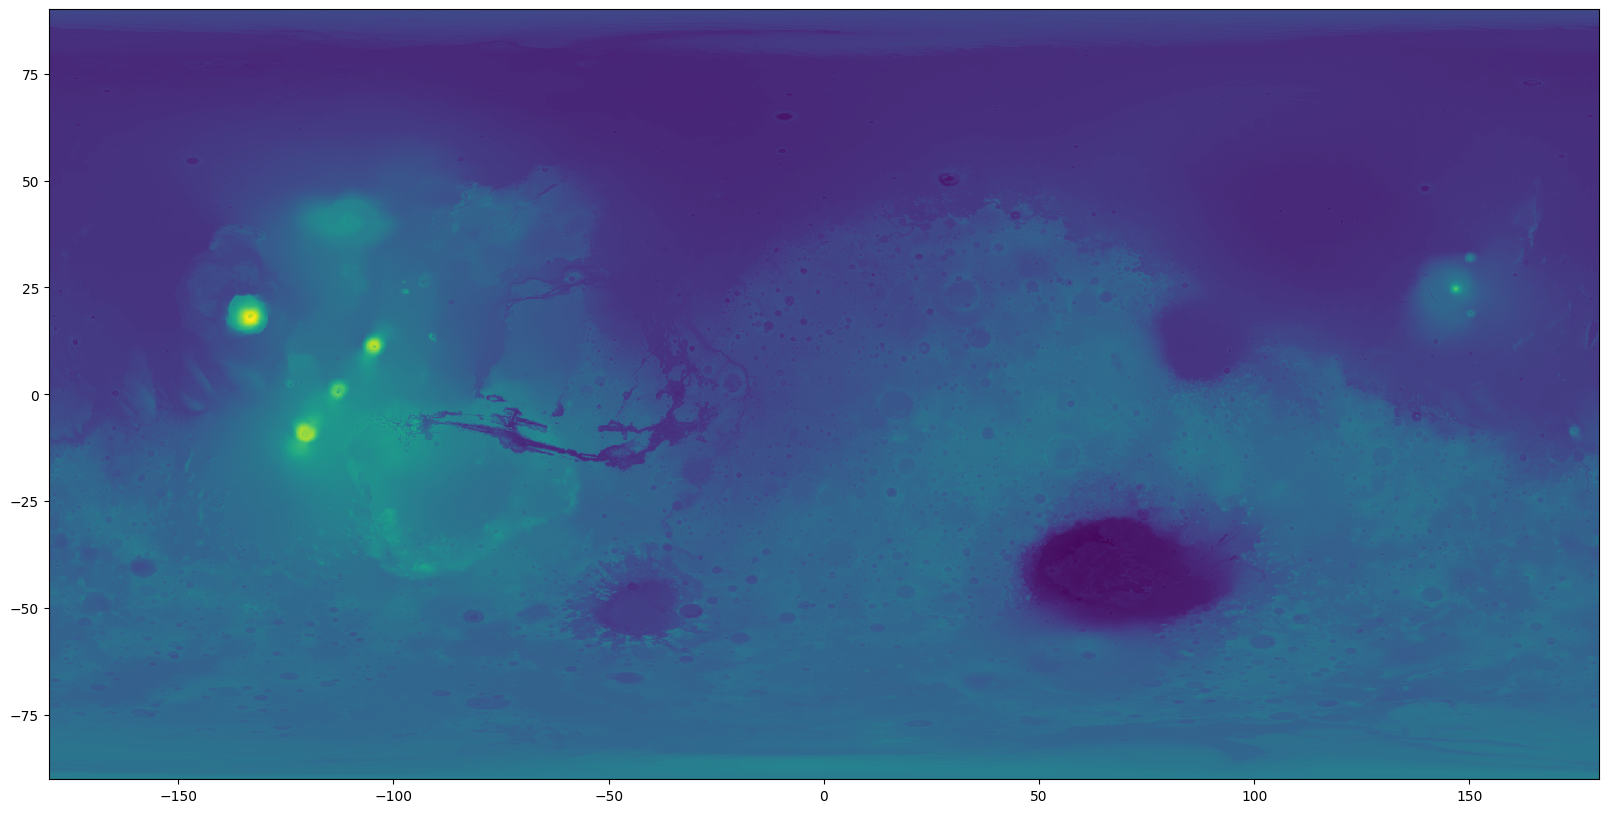

In [ ]:
fig, ax = plt.subplots(figsize=(20, 10)) #initialise a plot and set the size of it
plt.pcolormesh(lon, lat, dem)
#ax.grid() #adds a grid to the data but here I commented it because it isn't necessary
plt.savefig("example.png")
files.download("example.png")

Here we use pcolormesh which "Create[s] a pseudocolor plot with a non-regular rectangular grid." We build the grid to plot the data on, here it is a lat-lon grid.

##Exercise

Re-plot the pcolormesh above but with all the extra matplotlib code pieces until you get a nice plot.

Hint: you will need to put two plots on the same axes
Hint 2: you should probably use several code cells to make the code easier to read and parse

plot these points on it too:

(25.1, 109.7), (18.4, 77.5), (4.5, 135.9), (-4.6, 137.4), (-1.9, -6)

Now we will annotate each point

Finally we will save the figure using ```plt.savefig```

###NOTE

The figure is stored in the runtime memory so it won't be kept once you close the tab, if you want to save it properly either use:

```files.download("filename.png")```

or

```# mount drive```

```from google.colab import drive```

```drive.mount('/content/gdrive')```

```images_dir = '/content/gdrive/My Drive/Images'```

```plt.savefig(f"{images_dir}/filename.png")```


## 3.3 Lets load more data

We will be using the Natural Earth datasets which we already downloaded when we cloned the github repository above.

In [ ]:
countries = gpd.read_file("/content/Geol_methods_GIS-datascience-python/geospatial_data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")
countries

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,Admin-0 country,1,5,Republic of Serbia,SRB,0,2,Sovereign country,1,Republic of Serbia,...,None,None,None,None,None,None,None,None,None,"POLYGON ((18.82982 45.90887, 18.82984 45.90888..."
173,Admin-0 country,1,6,Montenegro,MNE,0,2,Sovereign country,1,Montenegro,...,None,None,None,None,None,None,None,None,None,"POLYGON ((20.0707 42.58863, 19.80161 42.50009,..."
174,Admin-0 country,1,6,Kosovo,KOS,0,2,Disputed,1,Kosovo,...,Admin-0 country,Unrecognized,Admin-0 country,Unrecognized,Admin-0 country,Admin-0 country,Admin-0 country,Admin-0 country,Unrecognized,"POLYGON ((20.59025 41.85541, 20.52295 42.21787..."
175,Admin-0 country,1,5,Trinidad and Tobago,TTO,0,2,Sovereign country,1,Trinidad and Tobago,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-61.68 10.76, -61.105 10.89, -60.895..."


In [ ]:
rivers = gpd.read_file("/content/Geol_methods_GIS-datascience-python/geospatial_data/ne_10m_rivers_lake_centerlines/ne_10m_rivers_lake_centerlines.shp")
rivers.head()

,dissolve,scalerank,featurecla,name,name_alt,rivernum,note,min_zoom,name_en,min_label,...,name_sv,name_tr,name_vi,name_zh,name_fa,name_he,name_uk,name_ur,name_zht,geometry
0,975River,9,River,None,None,975,None,7.1,None,8.1,...,None,None,None,None,None,None,None,None,None,"LINESTRING (22.75649 -20.47161, 22.79458 -20.4..."
1,976River,9,River,Rungwa,None,976,None,7.1,Rungwa,8.1,...,Rungwa,Rungwa,Sông Rungwa,伦瓜河,رونگوا,רונגווה,Рунгва,رنگوا,倫瓜河,"MULTILINESTRING ((32 -7.24993, 32.02793 -7.238..."
2,977River,9,River,Ligonha,None,977,None,7.1,Ligonha,8.1,...,Ligonha,Ligonha,Sông Ligonha,利戈尼亚河,لیگونها,ליגונה,Лігонха,لیگونہا,利戈尼亞河,"MULTILINESTRING ((39.12783 -16.86663, 39.12598..."
3,978River,9,River,Dongwe,None,978,None,7.1,Dongwe,8.1,...,Dongwe,Dongwe,Sông Dongwe,松威河,دونگوه,דונגווה,Донгве,ڈانگوے,東威河,"LINESTRING (25.5333 -14.58333, 25.49502 -14.59..."
4,979River,9,River,Cuito,None,979,None,7.1,Cuito,8.1,...,Cuito,Cuito,Sông Cuito,奎托河,کیتو,קיטו,Куіто,کیوٹو,奎托河,"MULTILINESTRING ((20.75 -17.99993, 20.75234 -1..."


Let's check the Coordinate Reference system (CRS) or Datum is the same for both shapefiles or they will not plot together.

In [ ]:
countries.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
rivers.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Axes: >

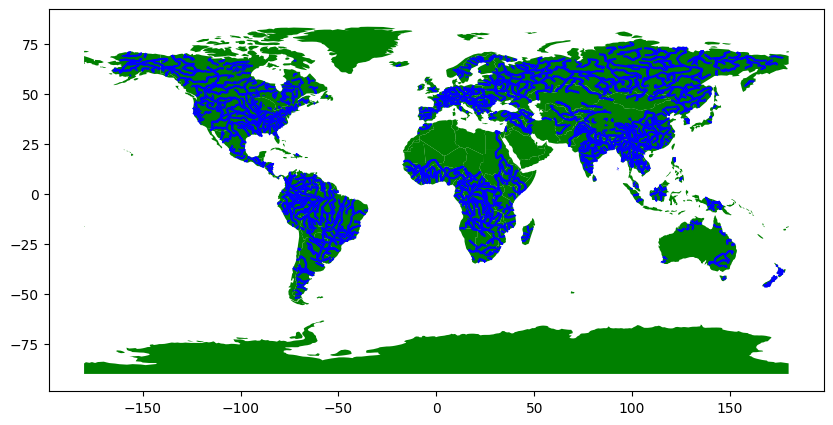

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5)) #initialise a plot and set the size of it
countries.plot(ax=ax, color='green')
rivers.plot(ax=ax, color='blue', marker='x')

Lets focus on just Europe, we can filter the data but there doesn't seem to be a simple way this time like ```ds_countries["continent"]=="Europe"```

We can do it for a specific country but not for all of Europe.

We can use a polygon to select a region. This is just one solution though, another would be to use another dataset which defines the boundary of Europe and use that, or to loop through the shapefile with a filter.

<Axes: >

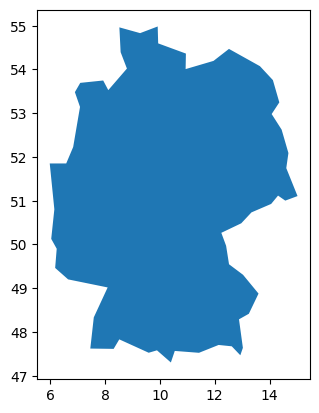

In [ ]:
germany = countries[countries["SOVEREIGNT"] == "Germany"]
germany.plot()

In [ ]:
polygon_extent = [(-14.262338, 35.490460), (-14.262338,60.462926), (27.152872, 60.462926), (27.152872, 35.490460)] #start at bottom left and go counterclockwise in coordinates

In [ ]:
europe_polygon = Polygon(polygon_extent) #use shapely polygon to make a polygon with predefined edges
poly_gdf = gpd.GeoDataFrame([1], geometry=[europe_polygon], crs=countries.crs)

<Axes: >

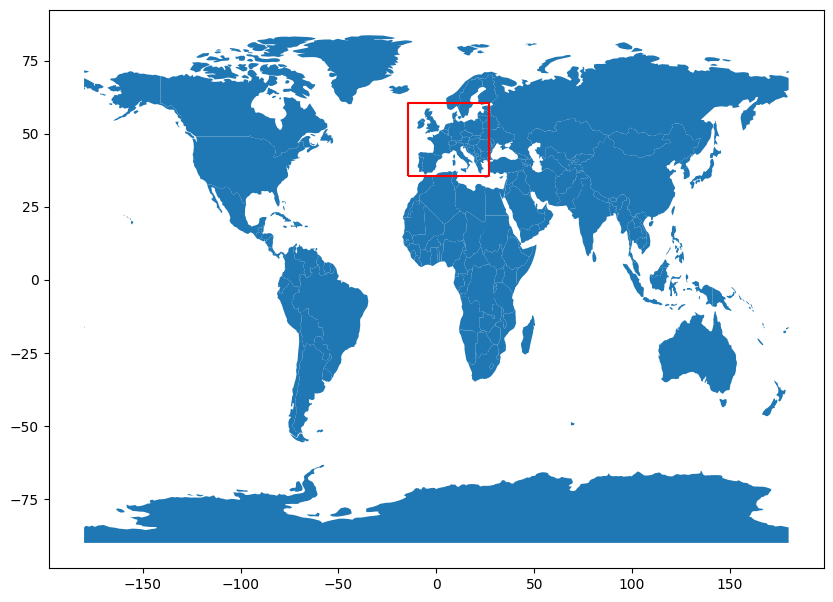

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8)) #initialise a plot and set the size of it
countries.plot(ax=ax)
poly_gdf.boundary.plot(ax=ax, color="red")

In [ ]:
europe = countries.clip(europe_polygon)
eu_rivers = rivers.clip(europe_polygon)

<Axes: >

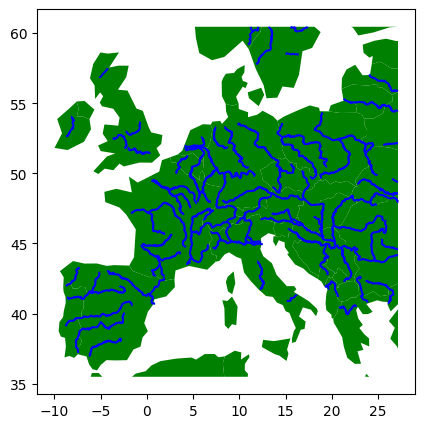

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5)) #initialise a plot and set the size of it
europe.plot(ax=ax, color='green')
eu_rivers.plot(ax=ax, color='blue')

## Exercise

Choose another region and make a new polygon mask then repeat what I just showed you and plot that region.

We can also add more data for example from the csv data from last week

In [ ]:
df = pd.read_csv("/content/Geol_methods_GIS-datascience-python/worldcities.csv")
df.head()

,city,city_ascii,lat,lng,country,iso2,iso3,admin_name,capital,population,id
0,Tokyo,Tokyo,35.6850,139.7514,Japan,JP,JPN,Tōkyō,primary,35676000.0,1392685764
1,New York,New York,40.6943,-73.9249,United States,US,USA,New York,NaN,19354922.0,1840034016
2,Mexico City,Mexico City,19.4424,-99.1310,Mexico,MX,MEX,Ciudad de México,primary,19028000.0,1484247881
3,Mumbai,Mumbai,19.0170,72.8570,India,IN,IND,Mahārāshtra,admin,18978000.0,1356226629
4,São Paulo,Sao Paulo,-23.5587,-46.6250,Brazil,BR,BRA,São Paulo,admin,18845000.0,1076532519


Again let's filter the data but lets filter more aggressively now.

In [ ]:
filter = ["Germany", "France"]

filtered_df = df[df['country'].isin(filter)]

filtered_df = filtered_df[filtered_df["population"]>1e6]

In [ ]:
filtered_df

,city,city_ascii,lat,lng,country,iso2,iso3,admin_name,capital,population,id
19,Paris,Paris,48.8667,2.3333,France,FR,FRA,Île-de-France,primary,9904000.0,1250015082
96,Berlin,Berlin,52.5218,13.4015,Germany,DE,DEU,Berlin,primary,3406000.0,1276451290
121,Stuttgart,Stuttgart,48.7800,9.2000,Germany,DE,DEU,Baden-Württemberg,admin,2944700.0,1276171358
127,Frankfurt,Frankfurt,50.1000,8.6750,Germany,DE,DEU,Hesse,minor,2895000.0,1276054552
172,Mannheim,Mannheim,49.5004,8.4700,Germany,DE,DEU,Baden-Württemberg,minor,2362000.0,1276150104
239,Hamburg,Hamburg,53.5500,10.0000,Germany,DE,DEU,Hamburg,admin,1757000.0,1276041799
246,Essen,Essen,51.4500,7.0166,Germany,DE,DEU,North Rhine-Westphalia,minor,1742135.0,1276769247
335,Lyon,Lyon,45.7700,4.8300,France,FR,FRA,Auvergne-Rhône-Alpes,admin,1423000.0,1250196189
341,Marseille,Marseille,43.2900,5.3750,France,FR,FRA,Provence-Alpes-Côte d’Azur,admin,1400000.0,1250774071
378,Duisburg,Duisburg,51.4300,6.7500,Germany,DE,DEU,North Rhine-Westphalia,minor,1276757.0,1276977172


Now we can plot the land, rivers, and the larger cities

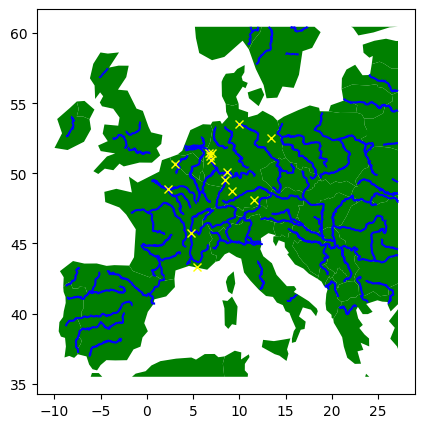

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5)) #initialise a plot and set the size of it
europe.plot(ax=ax, color='green')
eu_rivers.plot(ax=ax, color='blue')
ax.plot(filtered_df.lng, filtered_df.lat, linestyle="None", marker='x', color='yellow')

Interesting how the major cities are all on rivers 🤔

Change it so it only plots the capitals of each country in mainland Europe

If you finish early and want to then annotate each capital city with it's name (Knowing how to do this will be helpful for the course so do try to do it if you have time)